In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d as Axes3D



In [15]:
# Generate data with 2 features
np.random.seed(42)
m = 100 # number of training examples
X = np.c_[np.ones(m), np.random.rand(m), np.random.randn(m)] # Bias, feature 1, feature 2
true_theta = np.array([1, 2, -1.5])
y = X@true_theta + np.random.randn(m) * 0.3 # y = X@theta + noise

print("Data shape:", X.shape, y.shape)

print("First 5 examples:", X[:5,])
print("firs 5 targets", y[:5])



Data shape: (100, 3) (100,)
First 5 examples: [[ 1.          0.37454012  0.08704707]
 [ 1.          0.95071431 -0.29900735]
 [ 1.          0.73199394  0.09176078]
 [ 1.          0.59865848 -1.98756891]
 [ 1.          0.15601864 -0.21967189]]
firs 5 targets [1.6224102  3.78599986 2.24694967 5.99472109 1.82924532]


In [16]:
def compute_cost(X, y, theta):
    m = len(y)
    errors = X @ theta - y
    return (1 / (2 * m)) * np.sum(errors ** 2)

In [17]:
def gradient_decent(X, y, theta, alpha, num_iters):
    m = len(y)
    print(X.shape[0], len(y))
    cost_history = []
    theta_history = []

    for i in range(num_iters):
        predictions = X @ theta
        errors =  predictions - y
        gradient = X.T @ errors / m
        theta = theta - alpha * gradient
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        theta_history.append(theta)
    return theta, cost_history, theta_history

    J_history = np.zeros(num_iters)
    
    for i in range(num_iters):
        h = X@theta
        gradient = X.T@(h - y) / m
        

In [24]:
# Train
theta = np.zeros(X.shape[1])
alpha = 0.1
num_iters = 1000

theta_final, cost_history, theta_history = gradient_decent(X, y, theta, alpha, num_iters)

print(f"\nLearned theta: {theta_final}")
print(f"True theta: {true_theta}")
print(f"Difference: {np.abs(theta_final - true_theta)}")

100 100

Learned theta: [ 1.01197115  1.99812877 -1.50821296]
True theta: [ 1.   2.  -1.5]
Difference: [0.01197115 0.00187123 0.00821296]


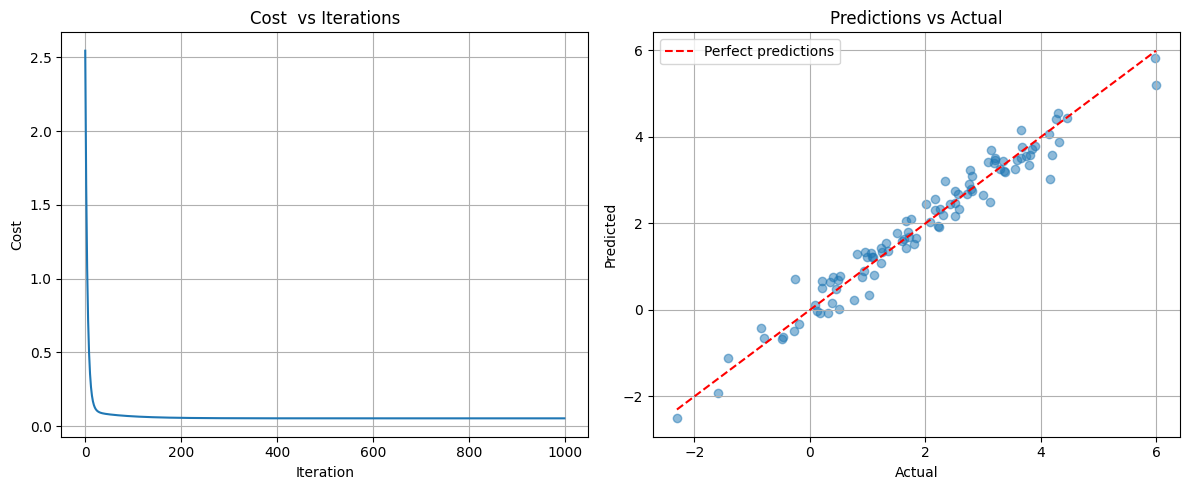

In [25]:
# Visualise in 3D
fig = plt.figure(figsize=(12, 5))

#Cost_history
ax1 = fig.add_subplot(121)
ax1.plot(cost_history)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cost')
ax1.set_title('Cost  vs Iterations')
ax1.grid(True)

# predictions vs actual

ax2 = fig.add_subplot(122)
predictions = X @ theta_final
ax2.scatter(y, predictions, alpha=0.5)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect predictions') # line plot of perfect predictions
ax2.legend()
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title('Predictions vs Actual')

ax2.grid(True)

plt.tight_layout()
plt.show()

# 3D plot




100 100
theta_1_vals: [-1.56177134 -1.50116528 -1.44055922 -1.37995316 -1.3193471  -1.25874104
 -1.19813498 -1.13752892 -1.07692286 -1.0163168  -0.95571074 -0.89510468
 -0.83449862 -0.77389255 -0.71328649 -0.65268043 -0.59207437 -0.53146831
 -0.47086225 -0.41025619 -0.34965013 -0.28904407 -0.22843801 -0.16783195
 -0.10722589 -0.04661983  0.01398623  0.07459229  0.13519835  0.19580442
  0.25641048  0.31701654  0.3776226   0.43822866  0.49883472  0.55944078
  0.62004684  0.6806529   0.74125896  0.80186502  0.86247108  0.92307714
  0.9836832   1.04428926  1.10489532  1.16550138  1.22610745  1.28671351
  1.34731957  1.40792563  1.46853169  1.52913775  1.58974381  1.65034987
  1.71095593  1.77156199  1.83216805  1.89277411  1.95338017  2.01398623
  2.07459229  2.13519835  2.19580442  2.25641048  2.31701654  2.3776226
  2.43822866  2.49883472  2.55944078  2.62004684  2.6806529   2.74125896
  2.80186502  2.86247108  2.92307714  2.9836832   3.04428926  3.10489532
  3.16550138  3.22610745  3.28

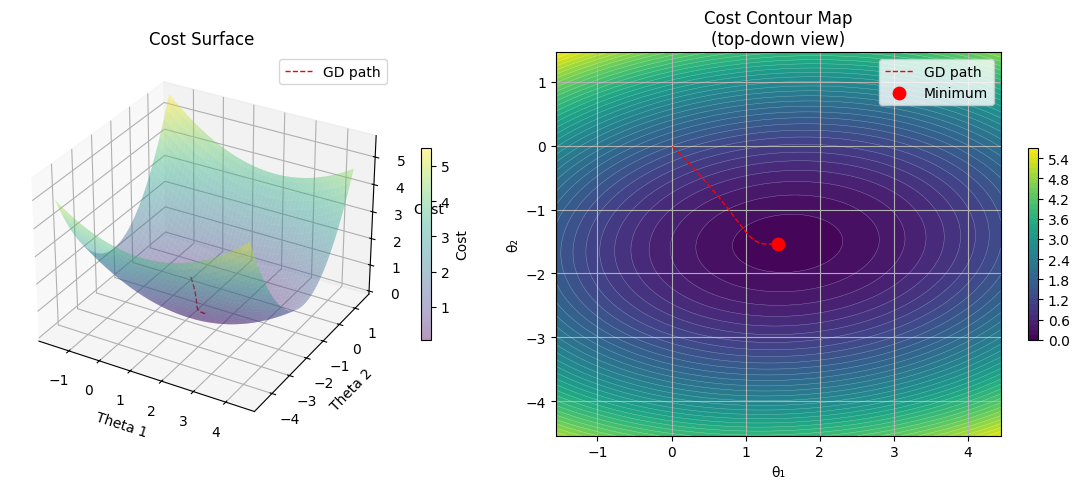

In [45]:
# for 3D COST surface plot
# fixing Theta_o at its learned value; sweeping through theta_1 and theta_2

theta_init = np.zeros(X.shape[1])
alpha = 0.01
num_iters = 1000

theta_final, cost_history, theta_history = gradient_decent(X, y, theta_init, alpha, num_iters)
theta_history = np.array(theta_history)

theta_1_vals = np.linspace(theta_final[1] - 3, theta_final[1] + 3, 100)
theta_2_vals = np.linspace(theta_final[2] - 3, theta_final[2] + 3, 100)

print(f"theta_1_vals: {theta_1_vals}")

T1, T2 = np.meshgrid(theta_1_vals, theta_2_vals)

print(f"T1: {T1.ravel()}")

# compute cost at every (theta_1, theta_2` pair`)

cost_grid = np.array([
    compute_cost(X, y, np.array([theta_final[0], t1, t2])) 
        for t1, t2 in zip(T1.ravel(), T2.ravel())]
        ).reshape(T1.shape)

# plot the cost surface

fig = plt.figure(figsize=(18, 5))

ax3 = fig.add_subplot(131, projection='3d')

surf = ax3.plot_surface(T1, T2, cost_grid, cmap='viridis', alpha=0.4)
ax3.plot(theta_history[:, 1], theta_history[:, 2],
         'r--', linewidth=1, markersize=2, label='GD path')
ax3.set_xlabel('Theta 1')
ax3.set_ylabel('Theta 2')
ax3.set_zlabel('Cost')
ax3.set_title('Cost Surface')
ax3.legend()

fig.colorbar(surf, ax=ax3, label='Cost', shrink=0.5)
ax3.grid(True)

ax4 = fig.add_subplot(132)
cp = ax4.contourf(T1, T2, cost_grid, levels=40, cmap='viridis')
ax4.contour(T1, T2, cost_grid, levels=40, colors='white', linewidths=0.3, alpha=0.4)

# print(theta_history)
ax4.plot(theta_history[:, 1], theta_history[:, 2],
         'r--', linewidth=1, markersize=2, label='GD path')
ax4.scatter(theta_final[1], theta_final[2], color='red', s=80, zorder=5, label='Minimum')
ax4.set_xlabel('θ₁')
ax4.set_ylabel('θ₂')
ax4.set_title('Cost Contour Map\n(top-down view)')
ax4.legend()
fig.colorbar(cp, ax=ax4, shrink=0.5)
ax4.grid(True)

plt.tight_layout()
plt.show()


# Explanation for using np.meshgrid

## why do we need to do np.meshgrid if the output of T1.ravel() and theta_1_range are the same .?

11:13 PM

Clarified that outputs differ fundamentally in size and dimensionality
Clarified that outputs differ fundamentally in size and dimensionality


Great question, but they are actually not the same. Let me show you exactly what's happening.

python
theta1_range = [1, 2, 3]   # simplified example
theta2_range = [10, 20, 30]
theta1_range is just a flat list of 3 values — [1, 2, 3]. That's it.

But when you do np.meshgrid:

python
T1, T2 = np.meshgrid(theta1_range, theta2_range)

# T1 looks like this:
# [[1, 2, 3],
#  [1, 2, 3],
#  [1, 2, 3]]

# T2 looks like this:
# [[10, 10, 10],
#  [20, 20, 20],
#  [30, 30, 30]]
```

Now when you `zip(T1.ravel(), T2.ravel())` you get **every combination** of θ₁ and θ₂:
```
(1, 10), (2, 10), (3, 10)
(1, 20), (2, 20), (3, 20)
(1, 30), (2, 30), (3, 30)
That's 9 pairs from 3+3 values. In your actual code it's 6400 pairs from 80+80 values.

If you only used theta1_range and theta2_range directly without meshgrid, you'd only get 80 pairs — (θ₁[0], θ₂[0]), (θ₁[1], θ₂[1])... — just a diagonal line of points across the grid, not the full grid. You'd have no surface to plot, just a curve.

The whole point of meshgrid is to say "give me every possible combination of these two axes" so you can compute cost at every cell of the grid, not just along the diagonal.